# Field inference of a single (realistic) source with the Fast Multipole Method

This notebook calcuates the potential of a single source via the Fast Multipole Method in 2D (https://github.com/flatironinstitute/fmm2d) and serves as a benchmark for our novel method.

Check for 2D magnetic field of a magnetized prism.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots  # noqa
import warnings

from hypermagnetics import plots
from hypermagnetics.sources import configure, read_db
from hypermagnetics.fmm_sources import potential2D, potential2D_loop, field2d_grid
from hypermagnetics.mt_eval import field_mt


warnings.filterwarnings('ignore')
plt.style.use(["science", "ieee"])

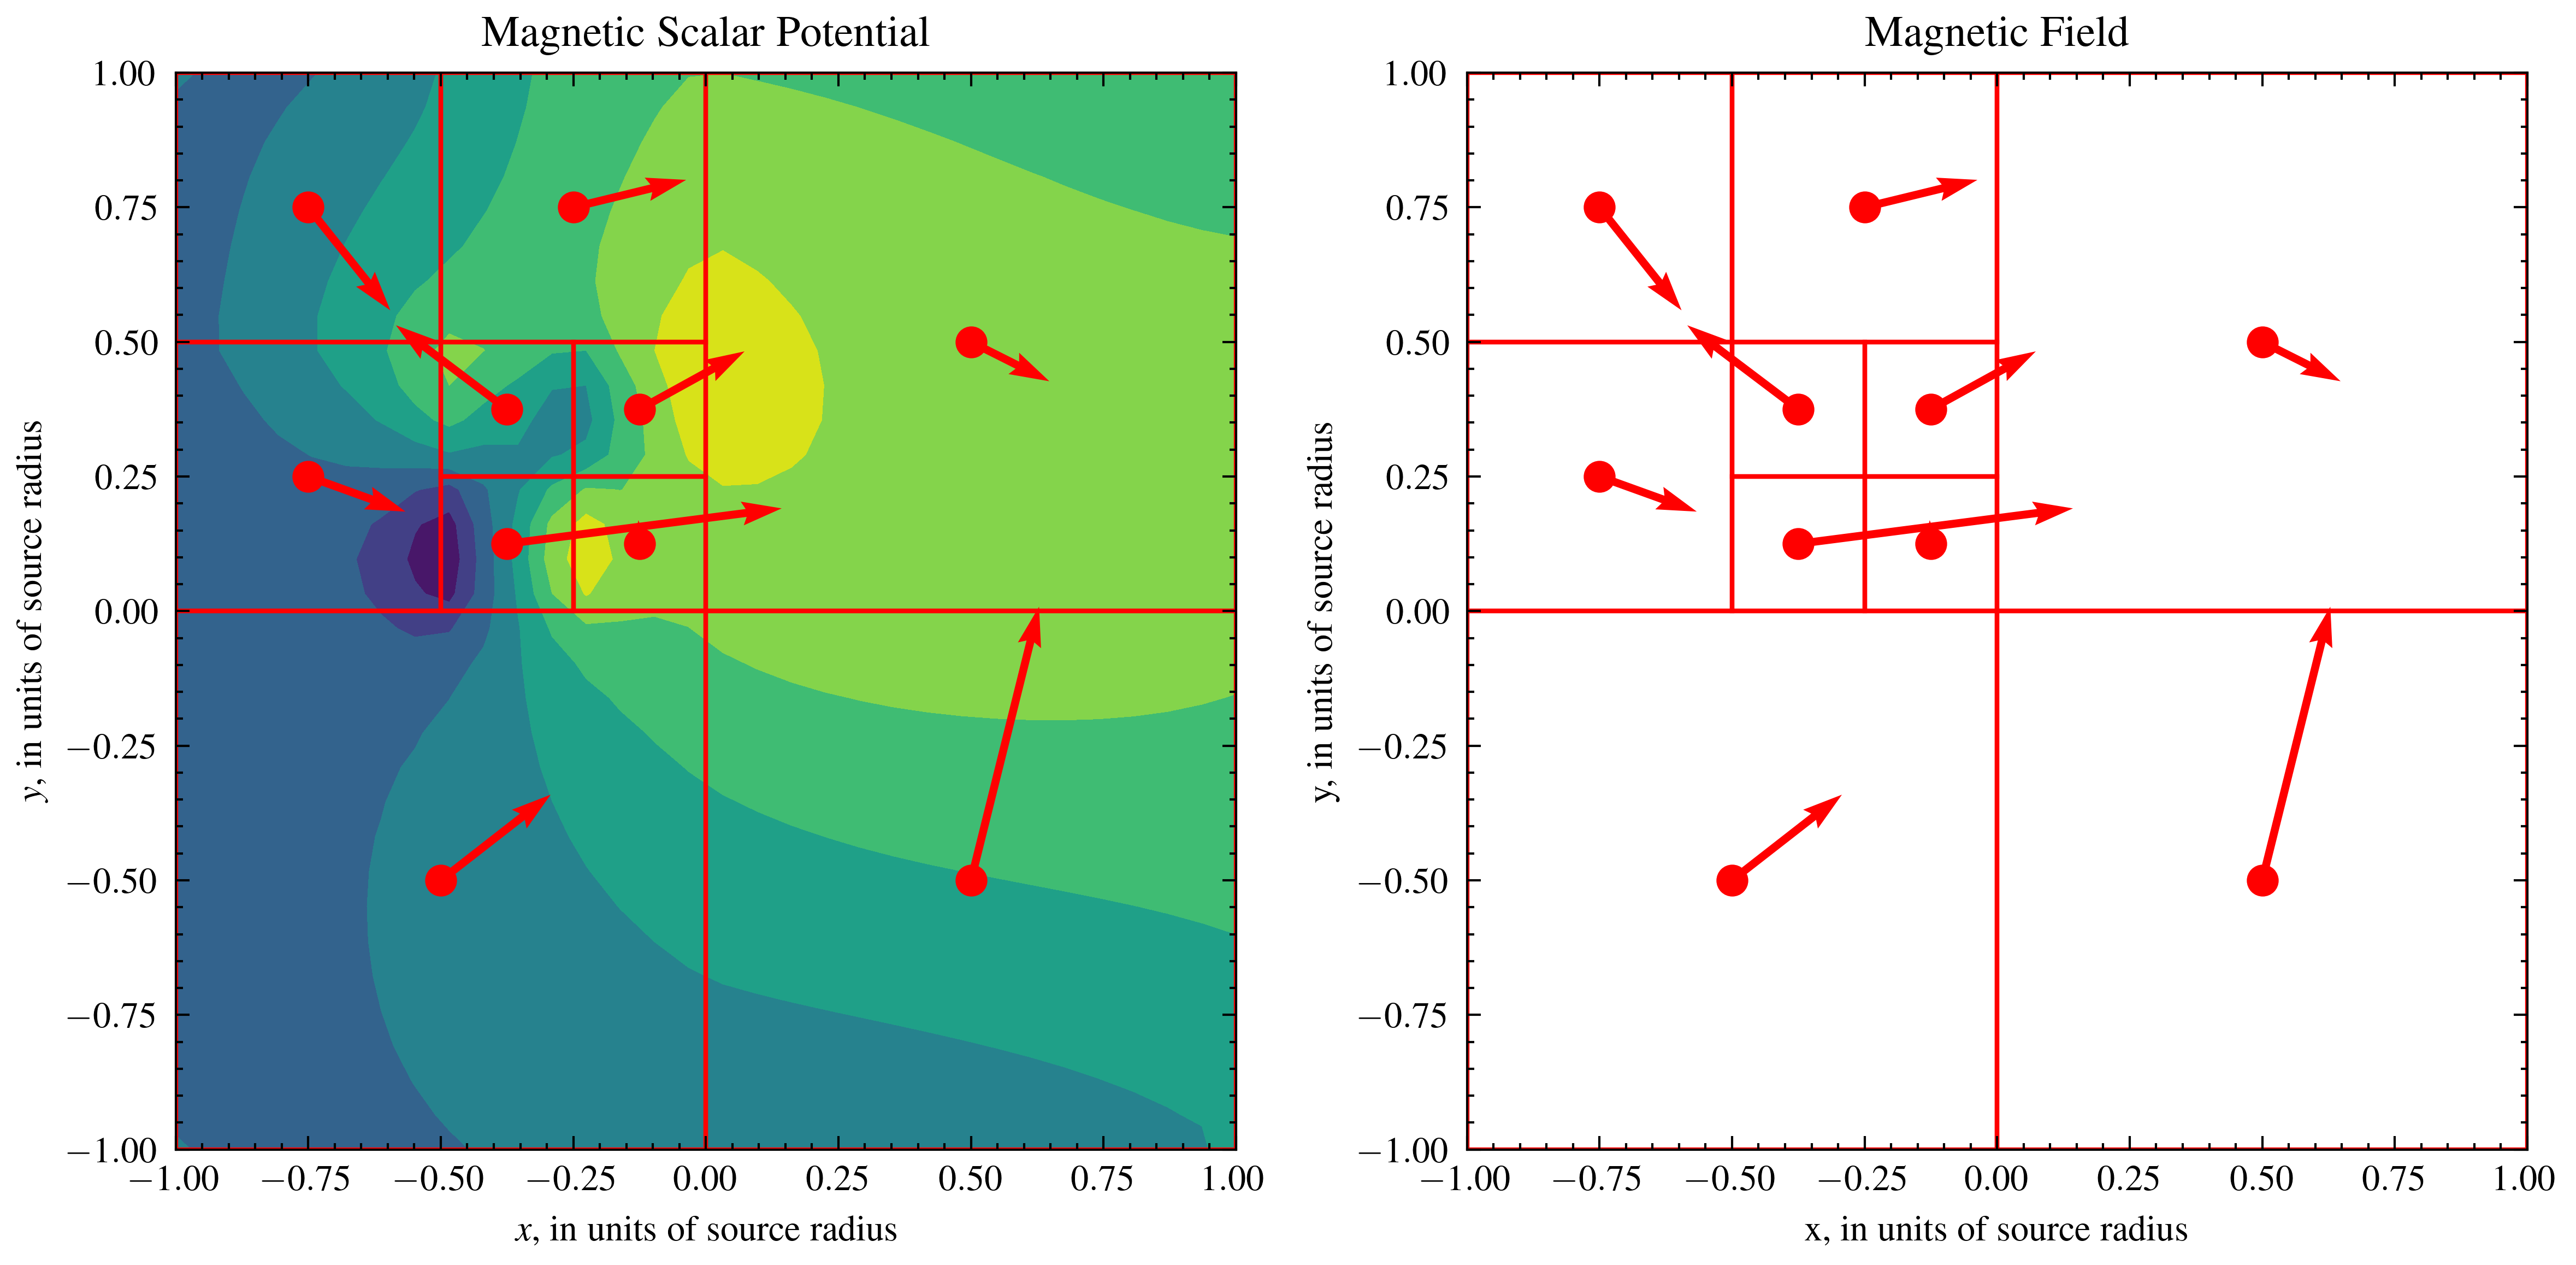

In [2]:
source_cfg = {
    "shape": "prism",
    "n_samples": 1,
    "n_sources": 12,
    "lim": 1,
    "res": 32,
    "dim": 2,
    "min_size": 0.5,
    "max_size": 1,
    "target_source": True,
    "line": False,
    "quadtree": True,
    "eps": 0,
    "seed": 0,
}
# train = configure(**source_cfg)
db_name = "eval_qt_exact_42"
train = read_db(f"{db_name}_{5}_{10}.h5", read_grid=True)
plots(train, loc=True, edge=True)

## Code from FMM2D
https://github.com/flatironinstitute/fmm2d/blob/main/src/laplace/rfmm2d.f#L144
- 2D dipole vector is represented in complex form `dx + i*dy`
- Can then be more easily treated as directional derivatives of monopole (source) potentials
- negative sign in `ztmp` is conventional; **TODO** Check how FMM is using this in Green's function

```
do i = 1,ns
    do j = 1,nd
        ztmp = -(dipvec(j,1,i)+eye*dipvec(j,2,i))
        dipstr1(j,i) = dipstr(j,i)*ztmp
    enddo
enddo
```


Potential: 0.08400030588421138


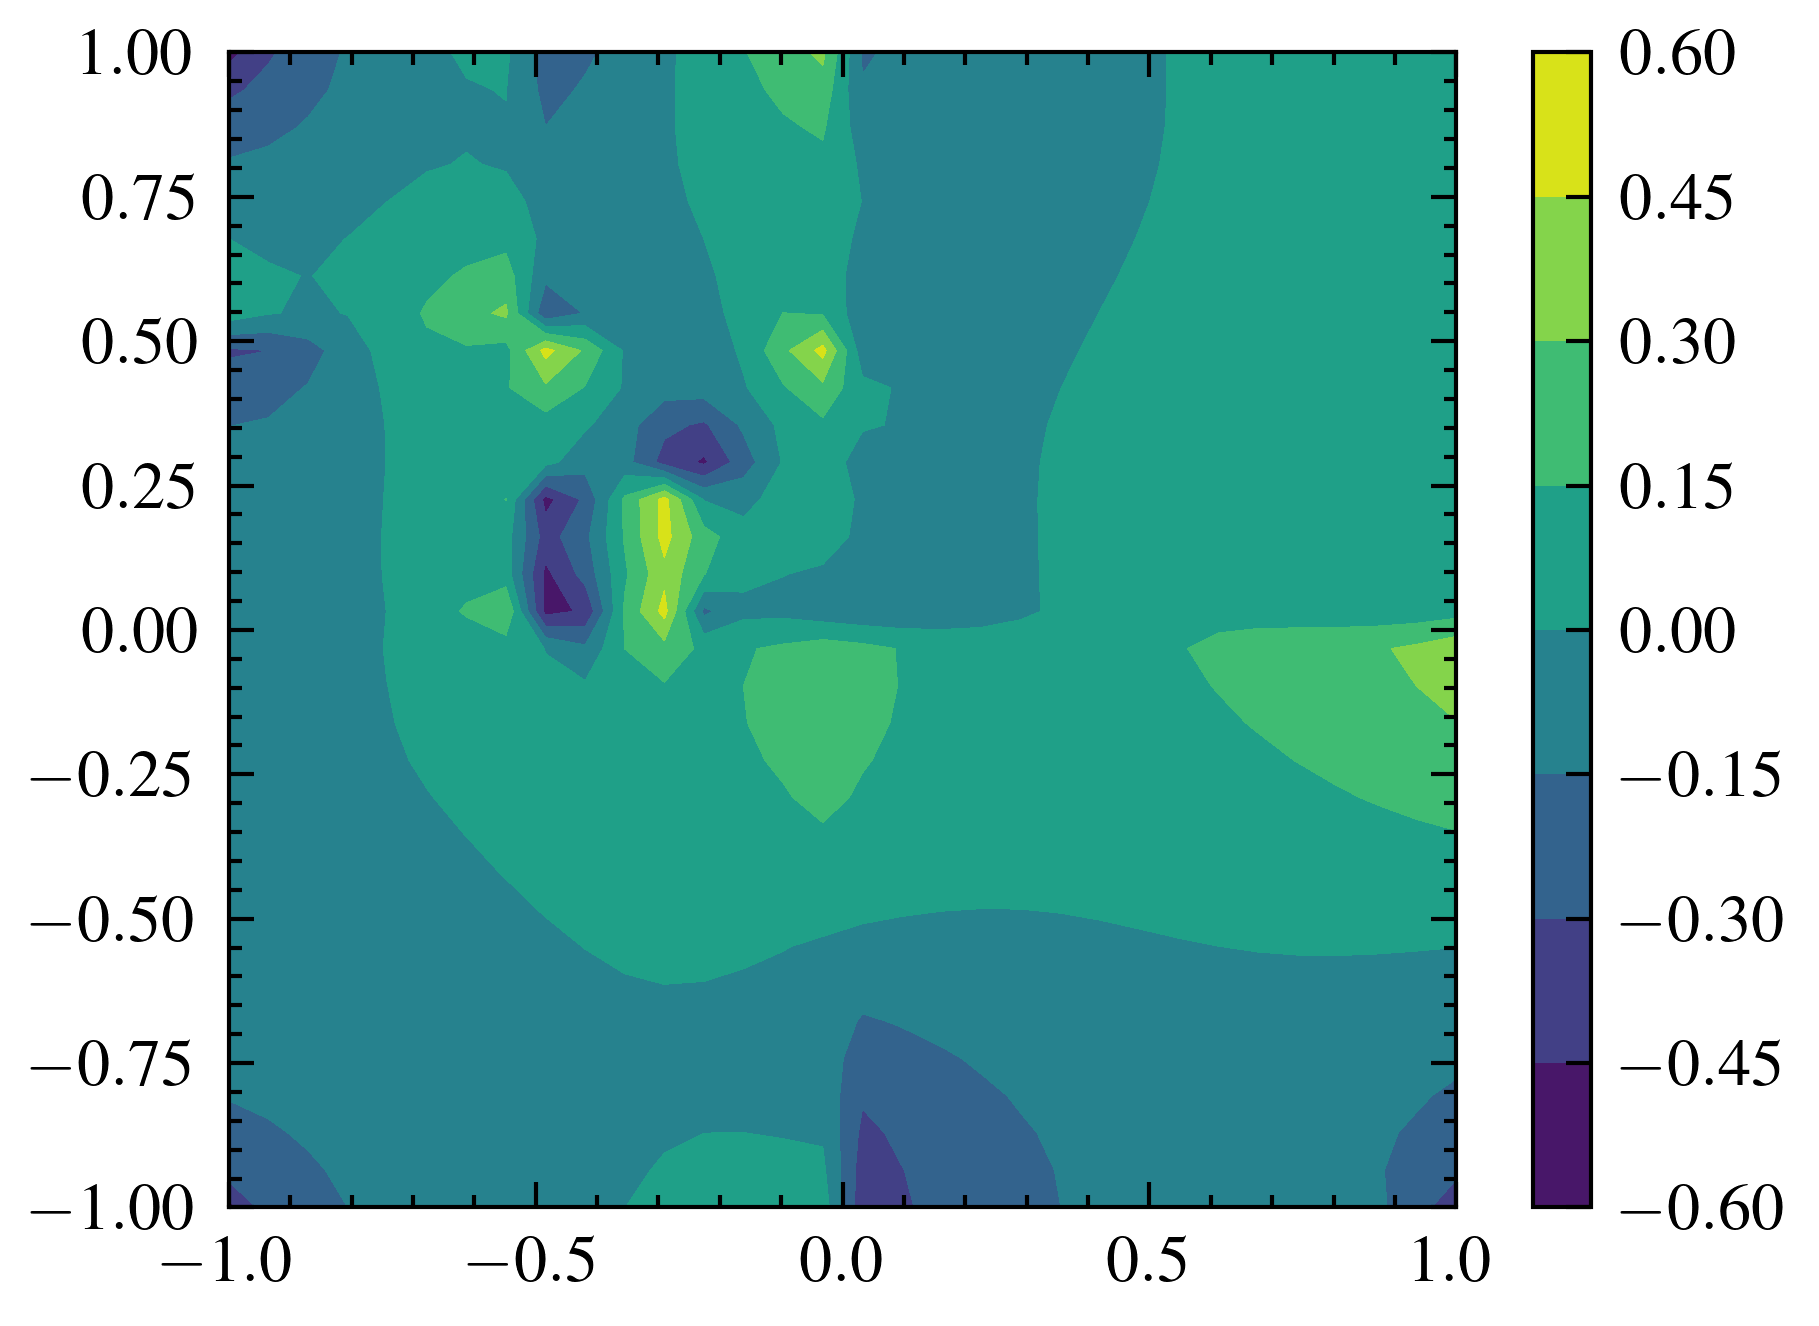

In [3]:
sim = train.copy()
sim['msp_grid'], _ = potential2D(sim['sources'], sim['shape'], sim['grid'], correction=True)

### Potential
if source_cfg["line"]:
    plt.plot(sim['grid'][:, 0], np.abs(sim["msp_grid"][0]))
    plt.plot(sim['grid'][:, 0], np.abs(train["msp_grid"][0]), color='red', linestyle='--')
    plt.plot(sim['grid'][:, 0], np.abs(train["msp_grid"][0] - sim["msp_grid"][0]), color='green', linestyle=':')
    plt.yscale("log")
    plt.legend(["Prism3D", "Dipole", "Error"])
else:
    x_grid = np.array(train['grid'][:, 0].reshape((source_cfg["res"], source_cfg["res"])))
    y_grid = np.array(train['grid'][:, 1].reshape((source_cfg["res"], source_cfg["res"])))
    sim_msp = sim["msp_grid"][0].reshape((source_cfg["res"], source_cfg["res"]))
    t_msp = train["msp_grid"][0].reshape((source_cfg["res"], source_cfg["res"]))
    # plt.contourf(x_grid, y_grid, sim_msp)
    plt.contourf(x_grid, y_grid, np.clip(sim_msp - t_msp, -0.5, 0.5))
    plt.colorbar()

print("Potential:", np.nanmean(np.abs(sim_msp - t_msp)))

Field(y): 3.959156099154556


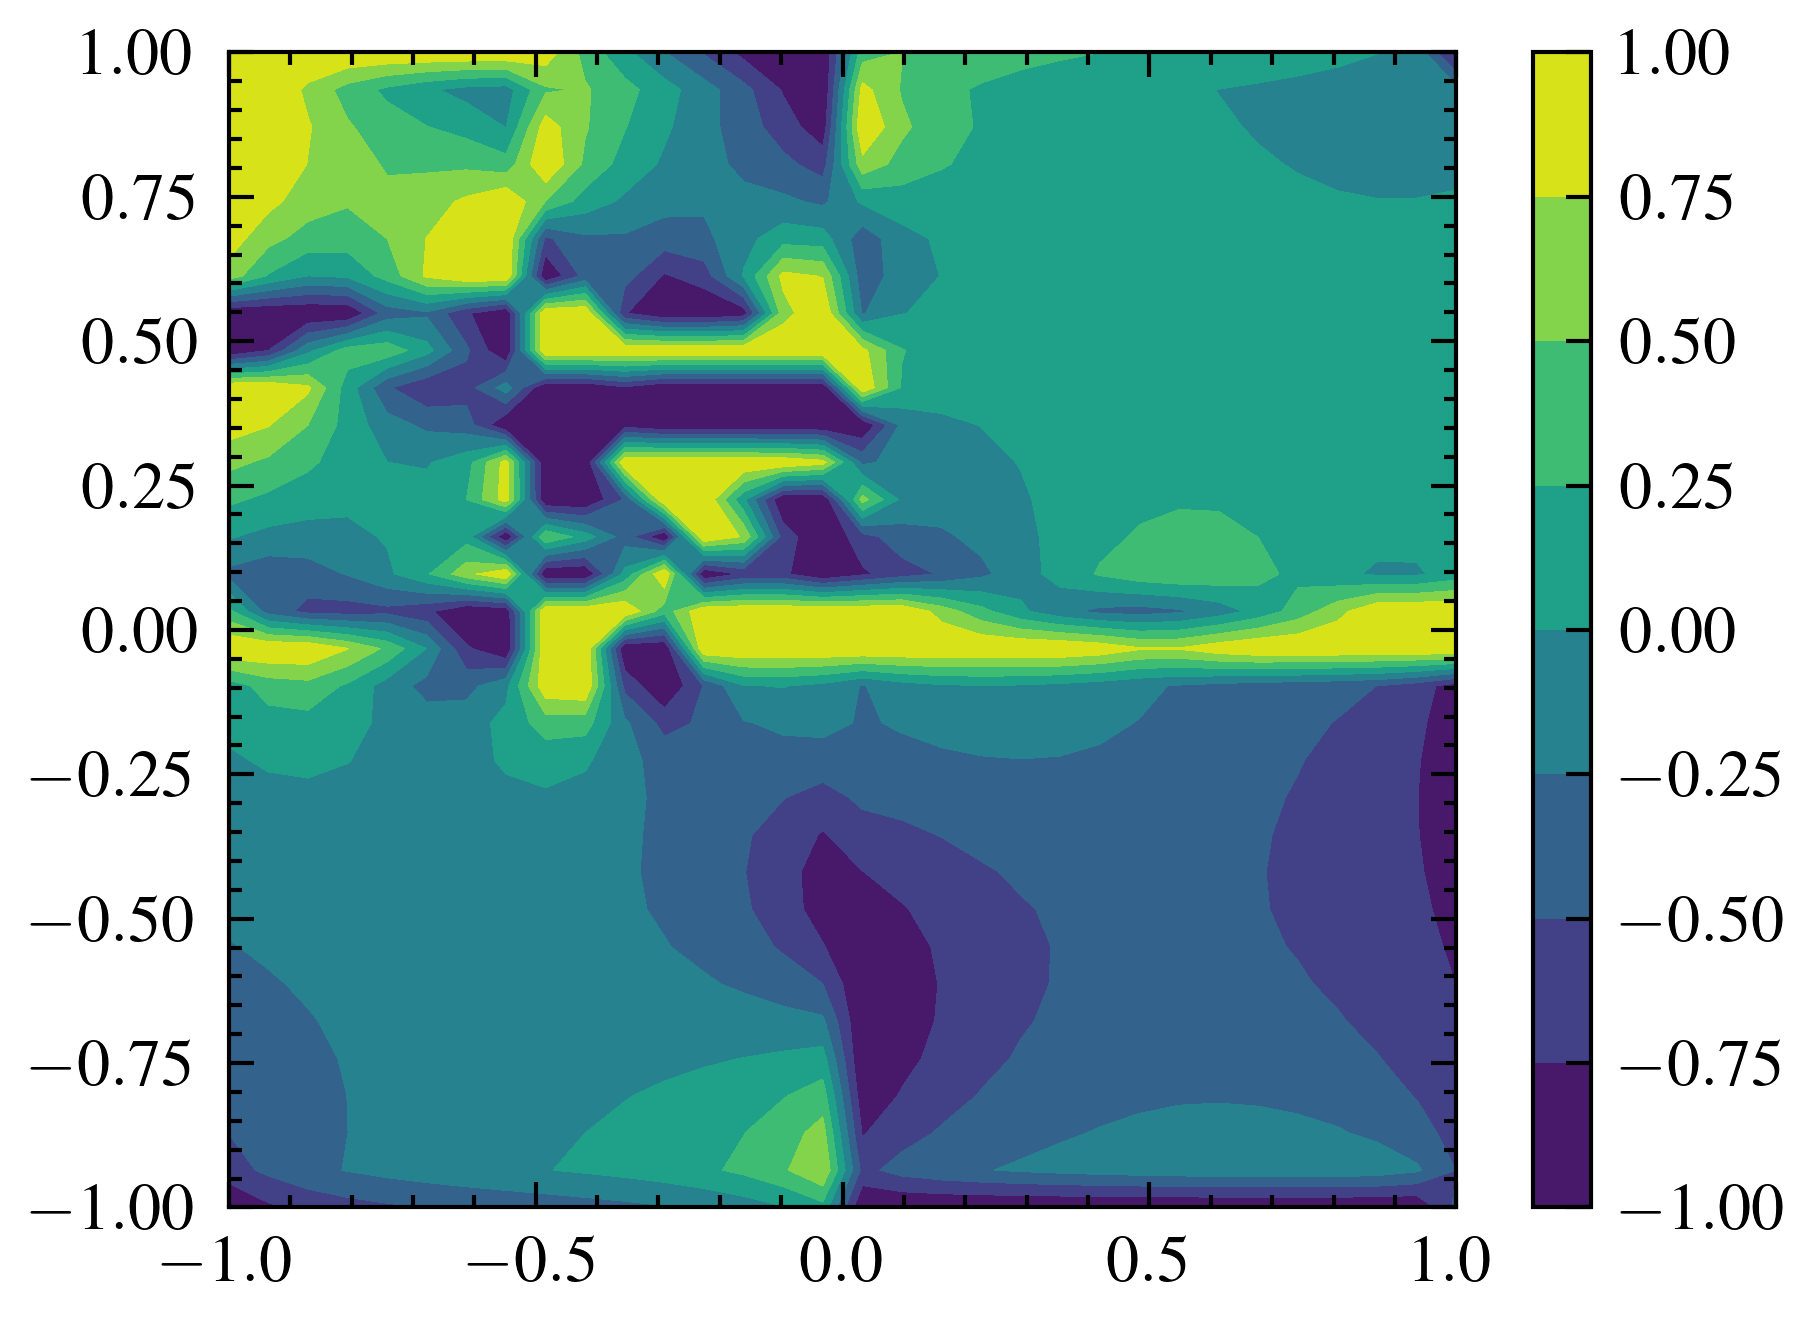

In [8]:
sim["field_grid"] = field2d_grid(source_cfg, sim["msp_grid"])
mt_sim, _ = field_mt(train['sources'], train['grid'], "prism")

### Field in x-direction
if source_cfg["line"]:
    plt.plot(sim['grid'][:, 0], np.abs(sim["field_grid"][0, ..., 0]))
    plt.plot(sim['grid'][:, 0], np.abs(train["field_grid"][0, ..., 0]), color='red', linestyle='--')
    plt.plot(sim['grid'][:, 0], np.abs(train["field_grid"][0] - sim["field_grid"][0]), color='green', linestyle=':')
    plt.yscale("log")
    plt.legend(["Prism3D", "Dipole", "Error"])
else:
    x_grid = np.array(train['grid'][:, 0].reshape((source_cfg["res"], source_cfg["res"])))
    y_grid = np.array(train['grid'][:, 1].reshape((source_cfg["res"], source_cfg["res"])))
    sim_f = sim["field_grid"][0, ..., 1].reshape((source_cfg["res"], source_cfg["res"]))
    t_f = mt_sim[0, ..., 1].reshape((source_cfg["res"], source_cfg["res"]))
    # plt.contourf(x_grid, y_grid, np.clip(sim_f, -5, 5))
    # plt.contourf(x_grid, y_grid, np.clip(t_f, -1, 1))
    plt.contourf(x_grid, y_grid, np.clip(sim_f - t_f, -1, 1))
    # plt.contourf(x_grid, y_grid, np.clip(sim_f / t_f, 0, 3))
    plt.colorbar()

    print("Field(y):", np.nanmean(np.abs(sim_f / t_f)))

## Directly from FMM2D

Field(y): 3.6154983377359313


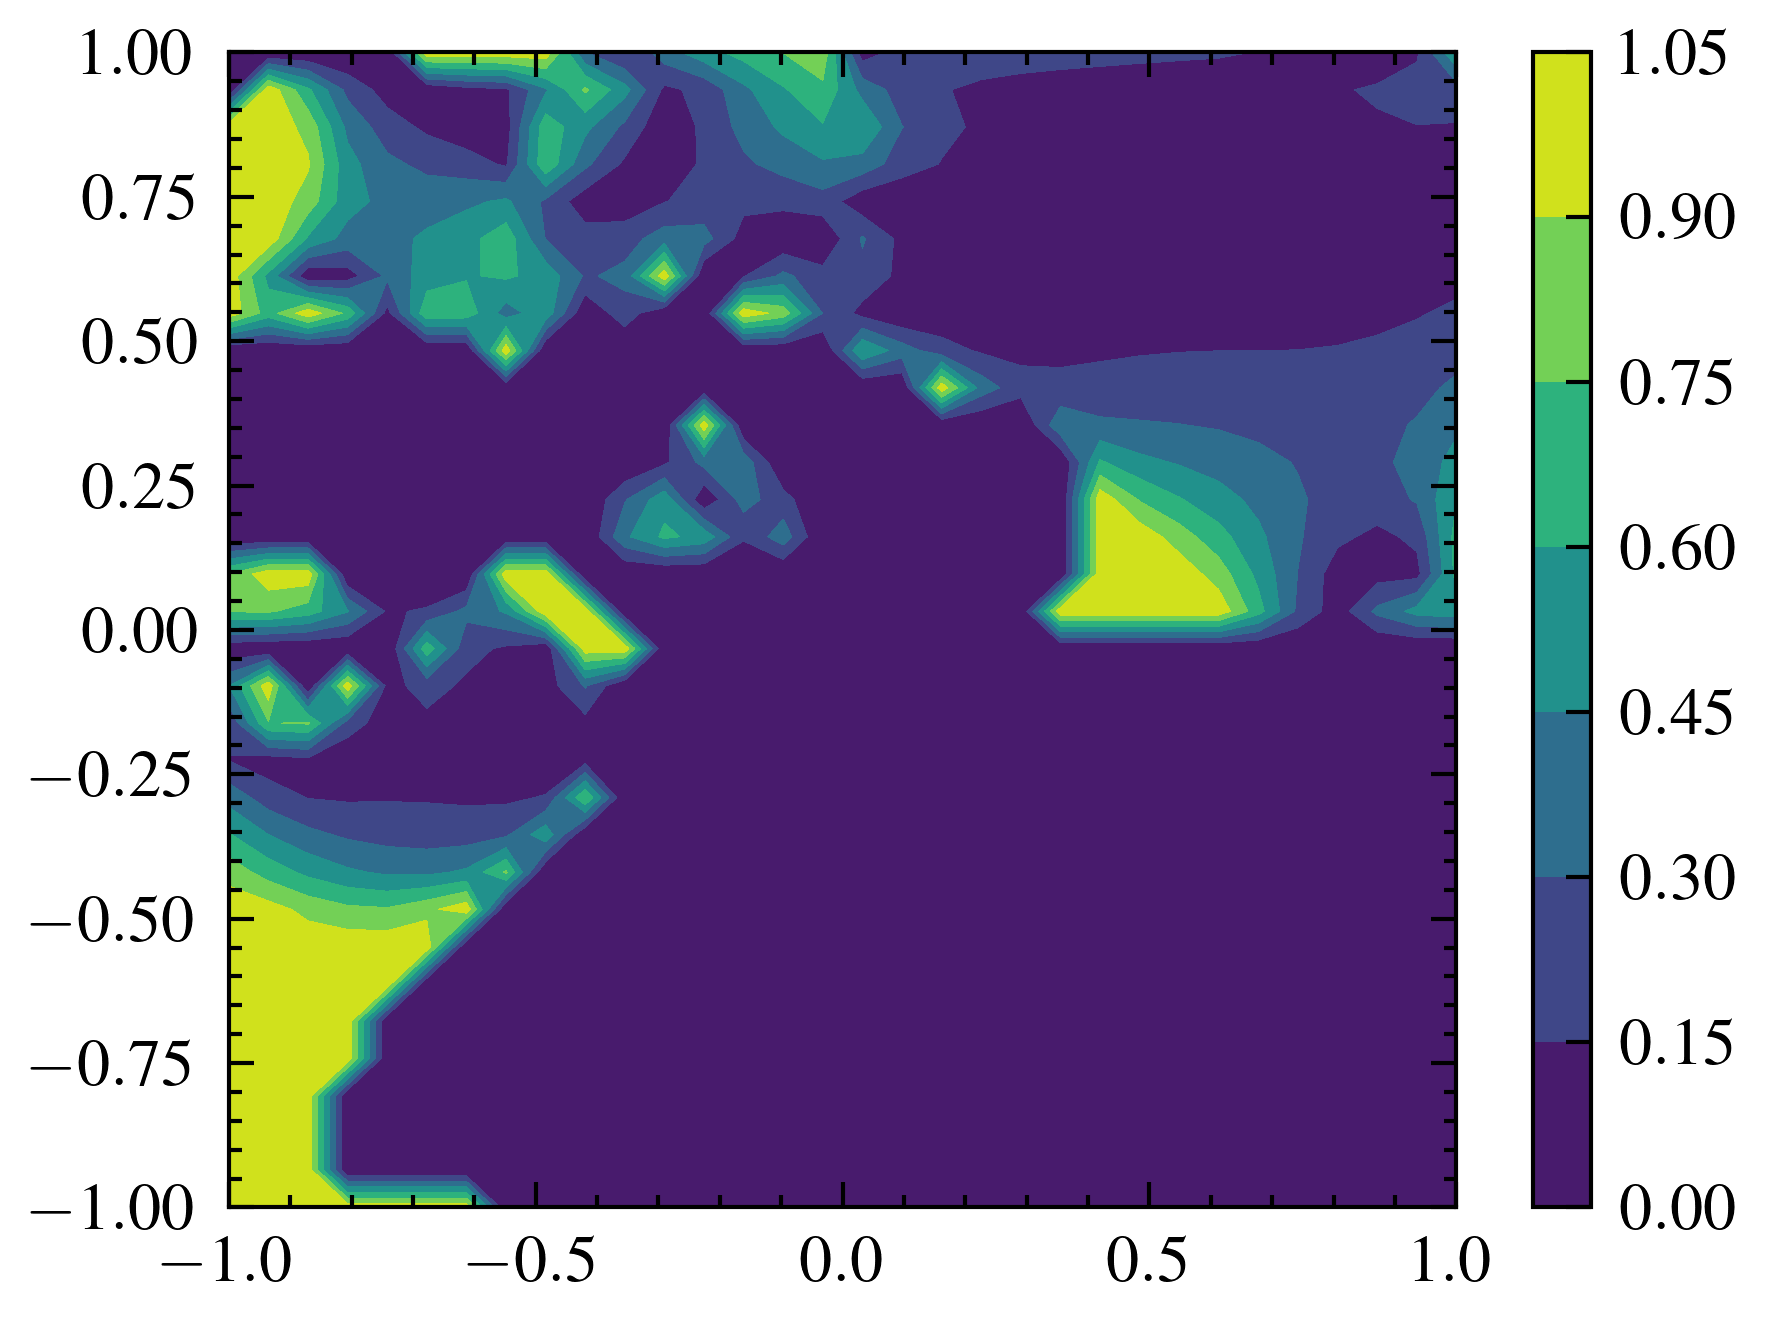

In [5]:
_, sim['field_grid_direct'] = potential2D(sim['sources'], sim['shape'], sim['grid'], correction=True)
# _, sim['field_grid_direct'] = potential2D_loop(sim['sources'], sim['shape'], sim['grid'])

### Field in x-direction
if source_cfg["line"]:
    plt.plot(sim['grid'][:, 0], np.abs(sim["field_grid_direct"][0, ..., 0]))
    plt.plot(sim['grid'][:, 0], np.abs(train["field_grid"][0, ..., 0]), color='red', linestyle='--')
    plt.plot(sim['grid'][:, 0], np.abs(train["field_grid"][0] - sim["field_grid_direct"][0]), color='green', linestyle=':')
    plt.yscale("log")
    plt.legend(["Prism3D", "Dipole", "Error"])
else:
    x_grid = np.array(train['grid'][:, 0].reshape((source_cfg["res"], source_cfg["res"])))
    y_grid = np.array(train['grid'][:, 1].reshape((source_cfg["res"], source_cfg["res"])))
    sim_f = sim["field_grid_direct"][0, ..., 1].reshape((source_cfg["res"], source_cfg["res"]))
    t_f = mt_sim[0, ..., 1].reshape((source_cfg["res"], source_cfg["res"]))
    # plt.contourf(x_grid, y_grid, np.clip(sim_f, -5, 5))
    # plt.contourf(x_grid, y_grid, np.clip(t_f, -1, 1))
    plt.contourf(x_grid, y_grid, np.clip(np.abs(sim_f - t_f) / t_f, 0, 1))
    # plt.contourf(x_grid, y_grid, np.clip(sim_f / t_f, 0, 3))
    plt.colorbar()

    print("Field(y):", np.nanmean(np.abs(sim_f / t_f)))

## Equivalent for MagTense
2D magnetiziation in $xy$-plane and prism is elongated in $z$-direction.

Convert magnetic moment to magnetization: $M = m / (2 * a * 2 * b)$

In [9]:
mt_sim, _ = field_mt(train['sources'], train['grid'], "prism")

if source_cfg["line"]:
    plt.plot(train['grid'][:, 0], train["field_grid"][0, ..., 0])
    plt.plot(train['grid'][:, 0], mt_sim[0, ..., 0], color='red', linestyle='--')
    # plt.plot(train['grid'][:, 0], train["field_grid"][0, ..., 0], color='red', linestyle='--')
    plt.plot(train['grid'][:, 0], mt_sim[0, ..., 0] / train["field_grid"][0, ..., 0], color='green', linestyle=':')
    # plt.yscale("log")
    # plt.xlim(5,15)
    plt.ylim(-2, 2)
    plt.legend(["Analytical", "MagTense", "Error"])
    print(np.nanmean(np.abs(mt_sim[0, :, 0] / train["field_grid"][0, :, 0])))

else:
    x_grid_pr = np.array(train['grid'][:, 0].reshape((source_cfg["res"], source_cfg["res"])))
    y_grid_pr = np.array(train['grid'][:, 1].reshape((source_cfg["res"], source_cfg["res"])))
    mt_f_grid_x = np.array(mt_sim[0, ..., 0].reshape((source_cfg["res"], source_cfg["res"])))
    t_f = train["field_grid"][0, ..., 0].reshape((source_cfg["res"], source_cfg["res"]))
    # plt.contourf(x_grid_pr, y_grid_pr, np.clip(np.abs(mt_f_grid_x - t_f), 0, 1))
    # plt.colorbar()
    print(np.nanmean(np.abs(mt_f_grid_x / t_f)))

nan


In [10]:
for eps in [0, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6]:
    mt_sim, _ = field_mt(train['sources'], train['r'][0] + eps, "prism")
    # print(np.mean(np.abs(mt_sim[0, ..., :2])))
    _, fmm_field = potential2D(sim['sources'], sim['shape'], sim['r'][0] + eps, correction=True)
    # _, fmm_field = potential2D_loop(sim['sources'], sim['shape'], sim['r'][0] + eps)
    # print(np.mean(np.abs(mt_sim[..., :2] - fmm_field)[0]))
    rel_err = np.abs((mt_sim[..., :2] - fmm_field) / mt_sim[..., :2]) * 100
    print(f"Eps: {eps:.1e}, Mean Error: {np.mean(rel_err):.2f} [%], Median Error: {np.median(rel_err):.2f} [%]")

Eps: 0.0e+00, Mean Error: 80.56 [%], Median Error: 34.80 [%]
Eps: 1.0e-01, Mean Error: 72.87 [%], Median Error: 31.39 [%]
Eps: 1.0e-02, Mean Error: 152.71 [%], Median Error: 32.71 [%]
Eps: 1.0e-03, Mean Error: 573.89 [%], Median Error: 33.80 [%]
Eps: 1.0e-04, Mean Error: 128.35 [%], Median Error: 46.99 [%]
Eps: 1.0e-05, Mean Error: 4828.68 [%], Median Error: 82.81 [%]
Eps: 1.0e-06, Mean Error: 1639893.69 [%], Median Error: 89.18 [%]
